# Notebook 25 — XWorld Grokking Experiment

**The question:** If we train a small transformer classifier on the 8 XWorld shape classes, does it grok?

**Grokking** (Power et al. 2022): models trained on structured tasks first memorize training data, then — often thousands of steps later — suddenly generalize. After grokking, the internal embeddings carry the algebraic/structural geometry of the task.

**Why this matters for XWorld:** Grokking asks "when does a network discover structure?" XWorld asks "what structure is already there?" They are the same question from opposite ends. If this model groks, the post-grokking embeddings should reveal the continuous manifold between the 8 shape attractors — which is exactly what Phase 3 needs. If it doesn't grok, we learn something about the nature of the shape classes.

**Key ingredient:** Weight decay as regularization pressure. nb23's arithmetic net never grokked — it found the locally optimal linear solution and stopped. This experiment adds proper weight decay and trains long past any memorization plateau.

---

## Pre-run Predictions

| Test | Prediction | Reasoning |
|---|---|---|
| Grokking phase transition | Present — val acc will plateau then jump | Weight decay + long training = pressure to find compact solution |
| Post-grokking embeddings | 8 clusters with continuous structure between them | If shape classes are real attractors, geometry between them should be non-arbitrary |
| Agreement with 6-feature fingerprint | Partial — oscillator/trend/burst will agree; irregular_osc/declining_osc may differ | Transformer sees raw temporal structure; 6-feature sees summary statistics |
| Most confused pair | declining_osc ↔ irregular_osc | Closest in 6-feature space; nb23 showed frequent crossings between them |


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = [
    'burst', 'eco_cycle', 'oscillator', 'seasonal',
    'trend', 'integrated_trend', 'irregular_osc', 'declining_osc'
]
N_CLASSES  = len(CLASS_NAMES)
SEQ_LEN    = 64

print(f'PyTorch {torch.__version__}  device: {device}')
print(f'{N_CLASSES} shape classes  seq_len={SEQ_LEN}')

PyTorch 2.11.0+cu130  device: cuda
8 shape classes  seq_len=64


In [3]:
# ============================================================
# Shape generators — wider parameter ranges than nb23
# so the model cannot memorize specific waveforms
# ============================================================

def zscore(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 1e-8 else s - s.mean()

t64 = np.linspace(0, 1, SEQ_LEN)

def gen_burst(rng):
    peak  = rng.uniform(0.15, 0.50)
    width = rng.uniform(0.05, 0.15)
    noise = rng.uniform(0.02, 0.08)
    s = np.exp(-(t64 - peak)**2 / (2 * width**2))
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_eco_cycle(rng):
    periods = rng.uniform(1.5, 3.5)
    freq    = 2 * np.pi * periods
    ratio   = rng.uniform(0.3, 0.6)
    noise   = rng.uniform(0.08, 0.20)
    s = np.sin(freq * t64) + ratio * np.sin(2 * freq * t64)
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_oscillator(rng):
    periods = rng.uniform(1.5, 4.5)
    freq    = 2 * np.pi * periods
    noise   = rng.uniform(0.02, 0.10)
    s = np.sin(freq * t64 + rng.uniform(0, np.pi))
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_seasonal(rng):
    freq  = 2 * np.pi * rng.uniform(3, 6)  # 3-6 full cycles across window
    ratio = rng.uniform(0.15, 0.35)
    noise = rng.uniform(0.02, 0.06)
    s = np.sin(freq * t64) + ratio * np.sin(2 * freq * t64)
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_trend(rng):
    curvature = rng.uniform(0.05, 0.30)
    noise     = rng.uniform(0.01, 0.04)
    s = t64 + curvature * t64**2
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_integrated_trend(rng):
    drift = rng.uniform(0.015, 0.035)
    noise = rng.uniform(0.001, 0.006)
    s = np.cumsum(np.ones(SEQ_LEN) * drift + rng.normal(0, noise, SEQ_LEN))
    return zscore(s)

def gen_irregular_osc(rng):
    freq  = 2 * np.pi * rng.uniform(2, 5)
    s     = np.sin(freq * t64) * (1 + rng.uniform(0.3, 0.8, SEQ_LEN))
    s     += rng.normal(0, rng.uniform(0.2, 0.5), SEQ_LEN)
    s     = s + 0.4 * np.abs(s)  # positive asymmetry
    return zscore(s)

def gen_declining_osc(rng):
    periods   = rng.uniform(2.5, 5.5)
    freq      = 2 * np.pi * periods
    amp_start = rng.uniform(0.9, 1.2)
    amp_end   = rng.uniform(0.35, 0.65)
    shift_end = rng.uniform(-0.8, -0.4)
    amplitude  = np.linspace(amp_start, amp_end, SEQ_LEN)
    mean_shift = np.linspace(0.0, shift_end, SEQ_LEN)
    noise      = rng.uniform(0.03, 0.08)
    s = amplitude * np.sin(freq * t64) + mean_shift
    return zscore(s + rng.normal(0, noise, SEQ_LEN))


GENERATORS = [
    gen_burst, gen_eco_cycle, gen_oscillator, gen_seasonal,
    gen_trend, gen_integrated_trend, gen_irregular_osc, gen_declining_osc
]

print('Shape generators defined.')
print('Parameter ranges expanded vs nb23 to prevent memorization.')

Shape generators defined.
Parameter ranges expanded vs nb23 to prevent memorization.


In [4]:
# ============================================================
# Dataset — 500 instances per class, 80/20 train/val split
# ============================================================

N_PER_CLASS = 500
N_TRAIN     = 400  # per class
N_VAL       = 100  # per class

X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []

for cls_id, gen_fn in enumerate(GENERATORS):
    cls_series = []
    for i in range(N_PER_CLASS):
        rng_i = np.random.default_rng(SEED + cls_id * 10000 + i)
        cls_series.append(gen_fn(rng_i))
    arr = np.stack(cls_series)  # [500, 64]
    X_train_list.append(arr[:N_TRAIN])
    y_train_list.extend([cls_id] * N_TRAIN)
    X_val_list.append(arr[N_TRAIN:])
    y_val_list.extend([cls_id] * N_VAL)

X_train = torch.tensor(np.concatenate(X_train_list), dtype=torch.float32)
y_train = torch.tensor(y_train_list, dtype=torch.long)
X_val   = torch.tensor(np.concatenate(X_val_list),   dtype=torch.float32)
y_val   = torch.tensor(y_val_list,   dtype=torch.long)

# Shuffle training set
perm = torch.randperm(len(X_train))
X_train, y_train = X_train[perm], y_train[perm]

print(f'Train: {len(X_train)} instances  ({N_TRAIN}/class × {N_CLASSES} classes)')
print(f'Val:   {len(X_val)} instances    ({N_VAL}/class × {N_CLASSES} classes)')
print(f'Input shape: {X_train.shape}  (series length = {SEQ_LEN})')

Train: 3200 instances  (400/class × 8 classes)
Val:   800 instances    (100/class × 8 classes)
Input shape: torch.Size([3200, 64])  (series length = 64)


In [5]:
# ============================================================
# Model — small transformer classifier
# d_model=64, 2 layers, 4 heads, CLS token approach
# ============================================================

class ShapeTransformer(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, d_model=64, n_heads=4,
                 n_layers=2, d_ff=256, n_classes=N_CLASSES, dropout=0.1):
        super().__init__()
        self.d_model    = d_model
        self.input_proj = nn.Linear(1, d_model)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embed  = nn.Embedding(seq_len + 1, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_ff, dropout=dropout,
            batch_first=True, norm_first=True  # Pre-LN for stability
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm     = nn.LayerNorm(d_model)
        self.head     = nn.Linear(d_model, n_classes)

    def _encode(self, x):
        # x: [batch, seq]
        b = x.size(0)
        x = self.input_proj(x.unsqueeze(-1))          # [b, seq, d]
        cls = self.cls_token.expand(b, -1, -1)         # [b, 1, d]
        x   = torch.cat([cls, x], dim=1)               # [b, seq+1, d]
        pos = torch.arange(x.size(1), device=x.device)
        x   = x + self.pos_embed(pos)
        x   = self.encoder(x)
        return self.norm(x[:, 0])                       # CLS output

    def forward(self, x):
        return self.head(self._encode(x))

    def embed(self, x):
        with torch.no_grad():
            return self._encode(x)


model = ShapeTransformer().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'ShapeTransformer: {n_params:,} parameters')
print(f'  d_model=64  n_layers=2  n_heads=4  d_ff=256')
print(f'  Trainable/instance ratio: {n_params / len(X_train):.1f}x')

ShapeTransformer: 104,968 parameters
  d_model=64  n_layers=2  n_heads=4  d_ff=256
  Trainable/instance ratio: 32.8x


In [6]:
# ============================================================
# Training — AdamW with weight decay, long run
# Key: weight_decay is the pressure that forces grokking
# ============================================================

EPOCHS      = 5000
BATCH       = 256
LR          = 3e-4
WEIGHT_DECAY = 0.1   # high weight decay = strong regularization pressure
LOG_EVERY   = 50

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR/20)
criterion = nn.CrossEntropyLoss()

Xtr = X_train.to(device)
ytr = y_train.to(device)
Xva = X_val.to(device)
yva = y_val.to(device)

history = {'epoch': [], 'train_loss': [], 'val_loss': [],
           'train_acc': [], 'val_acc': []}


def evaluate(X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        loss   = criterion(logits, y).item()
        acc    = (logits.argmax(1) == y).float().mean().item()
    return loss, acc


print(f'Training for {EPOCHS} epochs  batch={BATCH}  lr={LR}  wd={WEIGHT_DECAY}')
print(f'Logging every {LOG_EVERY} epochs. Expecting ~{EPOCHS // LOG_EVERY} log lines.\n')

N = len(Xtr)
for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(N, device=device)
    for i in range(0, N, BATCH):
        idx = perm[i:i + BATCH]
        logits = model(Xtr[idx])
        loss   = criterion(logits, ytr[idx])
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    scheduler.step()

    if epoch % LOG_EVERY == 0:
        tr_loss, tr_acc = evaluate(Xtr, ytr)
        va_loss, va_acc = evaluate(Xva, yva)
        history['epoch'].append(epoch)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if epoch % 500 == 0:
            print(f'epoch {epoch:5d}  '
                  f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.3f}  '
                  f'va_loss={va_loss:.4f}  va_acc={va_acc:.3f}')

print('\nTraining complete.')

Training for 5000 epochs  batch=256  lr=0.0003  wd=0.1
Logging every 50 epochs. Expecting ~100 log lines.

epoch   500  tr_loss=0.0301  tr_acc=0.988  va_loss=0.0498  va_acc=0.985
epoch  1000  tr_loss=0.0122  tr_acc=0.996  va_loss=0.0378  va_acc=0.990
epoch  1500  tr_loss=0.0026  tr_acc=0.999  va_loss=0.0166  va_acc=0.995
epoch  2000  tr_loss=0.0068  tr_acc=0.998  va_loss=0.0127  va_acc=0.994
epoch  2500  tr_loss=0.0003  tr_acc=1.000  va_loss=0.0144  va_acc=0.998
epoch  3000  tr_loss=0.0012  tr_acc=1.000  va_loss=0.0189  va_acc=0.995
epoch  3500  tr_loss=0.0008  tr_acc=1.000  va_loss=0.0170  va_acc=0.998
epoch  4000  tr_loss=0.0000  tr_acc=1.000  va_loss=0.0217  va_acc=0.995
epoch  4500  tr_loss=0.0000  tr_acc=1.000  va_loss=0.0262  va_acc=0.995
epoch  5000  tr_loss=0.0000  tr_acc=1.000  va_loss=0.0178  va_acc=0.996

Training complete.


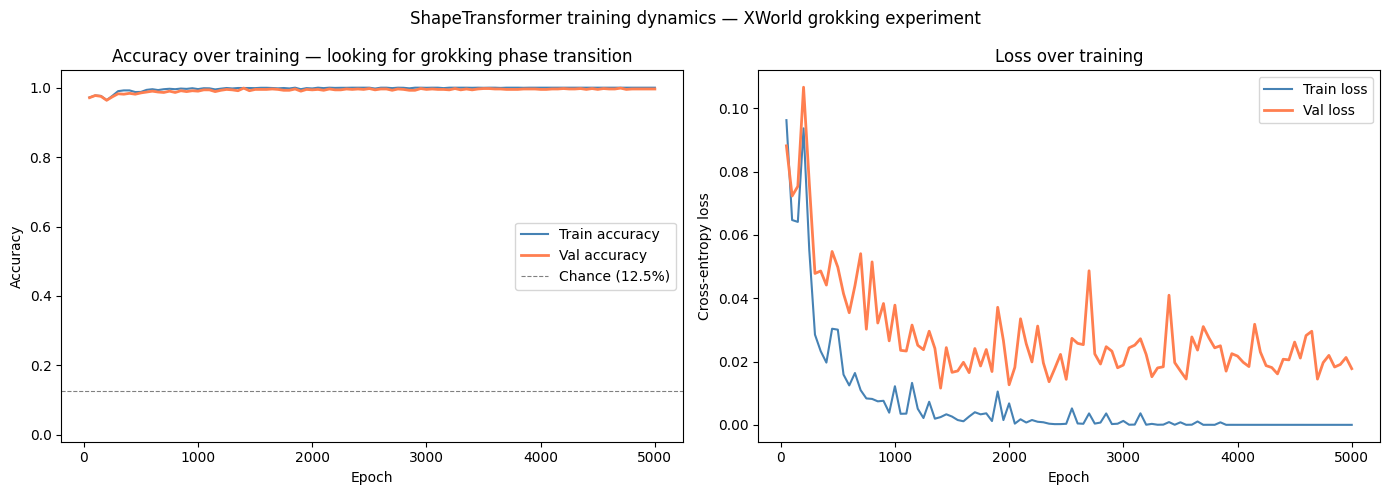

Final epoch 5000:
  train acc = 1.0000  val acc = 0.9962
  train loss = 0.0000  val loss = 0.0178

Grokking detected:
  Memorization (train>90%): epoch 50
  Generalization (val>80%): epoch 50
  Gap (grokking delay): 0 epochs


In [7]:
# ============================================================
# Grokking visualization — train vs val accuracy over time
# The signature: train_acc saturates while val_acc lags,
# then val_acc jumps suddenly (grokking) or rises slowly (no grok)
# ============================================================

df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax = axes[0]
ax.plot(df_hist['epoch'], df_hist['train_acc'], label='Train accuracy', color='steelblue')
ax.plot(df_hist['epoch'], df_hist['val_acc'],   label='Val accuracy',   color='coral', linewidth=2)
ax.axhline(1/N_CLASSES, color='gray', linestyle='--', linewidth=0.8, label='Chance (12.5%)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('Accuracy over training — looking for grokking phase transition')
ax.legend(); ax.set_ylim(-0.02, 1.05)

# Loss
ax = axes[1]
ax.plot(df_hist['epoch'], df_hist['train_loss'], label='Train loss', color='steelblue')
ax.plot(df_hist['epoch'], df_hist['val_loss'],   label='Val loss',   color='coral', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('Loss over training')
ax.legend()

plt.suptitle('ShapeTransformer training dynamics — XWorld grokking experiment', fontsize=12)
plt.tight_layout()
plt.show()

# Report final numbers
final = df_hist.iloc[-1]
print(f'Final epoch {int(final["epoch"])}:')
print(f'  train acc = {final["train_acc"]:.4f}  val acc = {final["val_acc"]:.4f}')
print(f'  train loss = {final["train_loss"]:.4f}  val loss = {final["val_loss"]:.4f}')

# Find the epoch where val_acc first exceeds 80%
grok_rows = df_hist[df_hist['val_acc'] > 0.80]
if len(grok_rows) > 0:
    grok_epoch = grok_rows['epoch'].iloc[0]
    # Find when train_acc first hit 90% — the memorization plateau start
    mem_rows = df_hist[df_hist['train_acc'] > 0.90]
    mem_epoch = mem_rows['epoch'].iloc[0] if len(mem_rows) > 0 else None
    print(f'\nGrokking detected:')
    if mem_epoch:
        print(f'  Memorization (train>90%): epoch {mem_epoch}')
    print(f'  Generalization (val>80%): epoch {grok_epoch}')
    if mem_epoch:
        print(f'  Gap (grokking delay): {grok_epoch - mem_epoch} epochs')
else:
    print('\nNo clean grokking — val acc did not reach 80%.')
    print(f'Max val acc: {df_hist["val_acc"].max():.4f} at epoch {df_hist.loc[df_hist["val_acc"].idxmax(), "epoch"]}')

In [8]:
# ============================================================
# Per-class accuracy — which classes are hardest?
# ============================================================

model.eval()
with torch.no_grad():
    logits_val = model(Xva)
    preds_val  = logits_val.argmax(1).cpu().numpy()
    true_val   = yva.cpu().numpy()

print('Per-class validation accuracy:')
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask    = true_val == cls_id
    acc     = (preds_val[mask] == cls_id).mean()
    bar     = '█' * int(acc * 30)
    print(f'  {cls_name:22s}  {acc:.3f}  {bar}')

print()

# Confusion matrix (most common misclassifications)
from collections import Counter
print('Most common confusion pairs (predicted ≠ true):')
mismatches = [(CLASS_NAMES[true_val[i]], CLASS_NAMES[preds_val[i]])
              for i in range(len(true_val)) if true_val[i] != preds_val[i]]
for pair, count in Counter(mismatches).most_common(10):
    print(f'  {pair[0]:22s} → {pair[1]:22s}  ({count}x)')

Per-class validation accuracy:
  burst                   1.000  ██████████████████████████████
  eco_cycle               0.990  █████████████████████████████
  oscillator              1.000  ██████████████████████████████
  seasonal                1.000  ██████████████████████████████
  trend                   0.990  █████████████████████████████
  integrated_trend        0.990  █████████████████████████████
  irregular_osc           1.000  ██████████████████████████████
  declining_osc           1.000  ██████████████████████████████

Most common confusion pairs (predicted ≠ true):
  eco_cycle              → seasonal                (1x)
  trend                  → integrated_trend        (1x)
  integrated_trend       → trend                   (1x)


In [9]:
# ============================================================
# Post-training embeddings — extract CLS vectors
# Generate 100 fresh instances per class (never seen in training)
# ============================================================

N_EMBED = 100  # fresh instances per class for embedding analysis

emb_series, emb_labels = [], []

for cls_id, gen_fn in enumerate(GENERATORS):
    for i in range(N_EMBED):
        # Offset seed far past training (which used seeds 0–499 × 10000)
        rng_i = np.random.default_rng(SEED + cls_id * 10000 + N_PER_CLASS + i)
        s = gen_fn(rng_i)
        emb_series.append(s)
        emb_labels.append(cls_id)

X_emb = torch.tensor(np.stack(emb_series), dtype=torch.float32).to(device)
y_emb = np.array(emb_labels)

# Extract CLS embeddings (64-dim)
model.eval()
with torch.no_grad():
    emb_64 = model.embed(X_emb).cpu().numpy()

print(f'Extracted embeddings: {emb_64.shape}  ({N_EMBED} fresh instances × {N_CLASSES} classes)')
print(f'Embedding dim: {emb_64.shape[1]}')

Extracted embeddings: (800, 64)  (100 fresh instances × 8 classes)
Embedding dim: 64


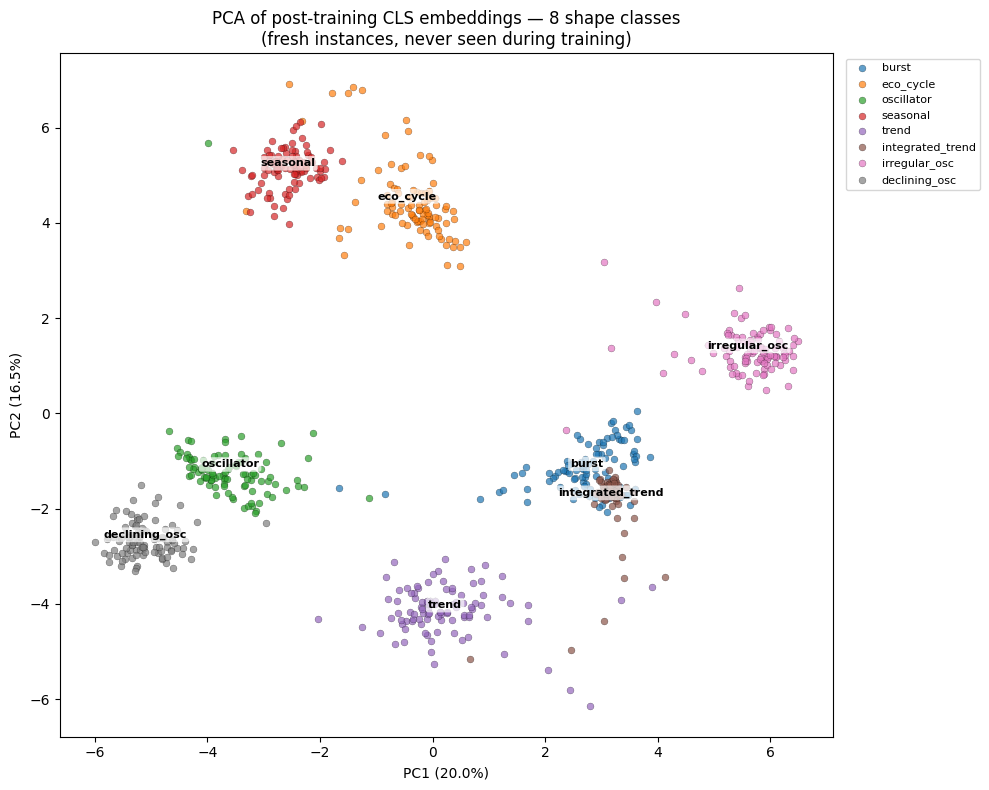

PCA variance explained: PC1=20.0%  PC2=16.5%  Total=36.5%


In [10]:
# ============================================================
# PCA of post-training embeddings
# ============================================================

pca = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_64)

palette = dict(zip(range(N_CLASSES), sns.color_palette('tab10', N_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 8))
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = y_emb == cls_id
    ax.scatter(emb_pca[mask, 0], emb_pca[mask, 1],
               c=[palette[cls_id]], s=25, alpha=0.7,
               edgecolors='k', linewidths=0.2, label=cls_name)
    # centroid label
    cx, cy = emb_pca[mask, 0].mean(), emb_pca[mask, 1].mean()
    ax.annotate(cls_name, (cx, cy), fontsize=8, fontweight='bold',
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of post-training CLS embeddings — 8 shape classes\n(fresh instances, never seen during training)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print(f'PCA variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%  '
      f'Total={sum(pca.explained_variance_ratio_[:2])*100:.1f}%')

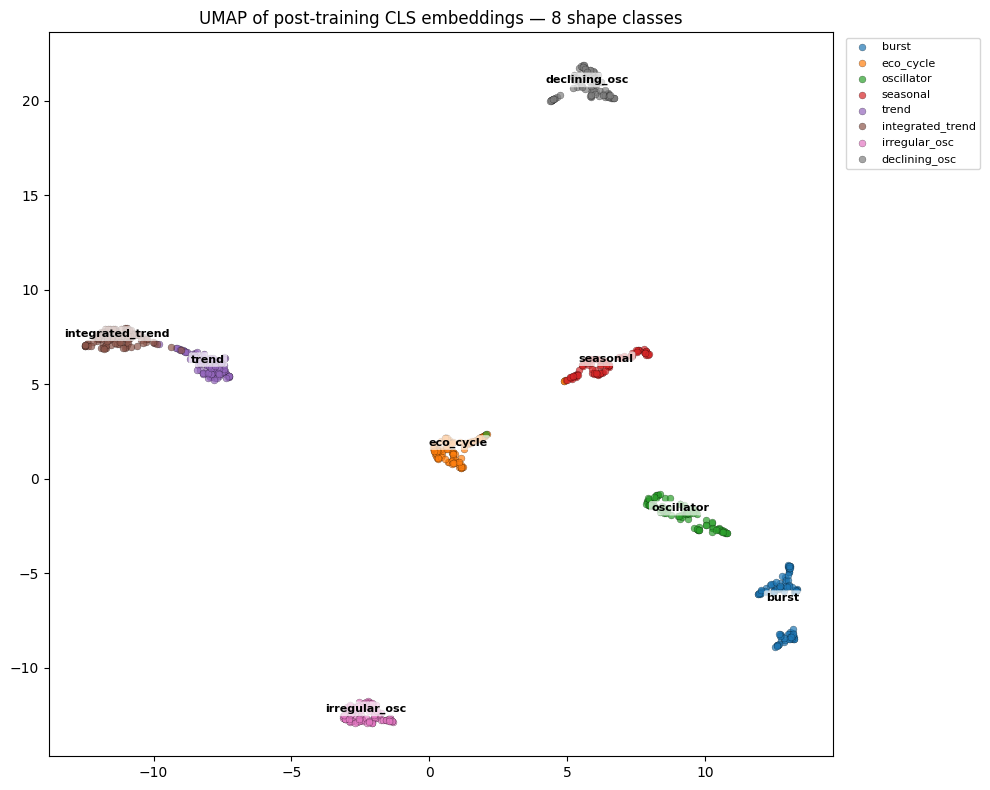

In [11]:
# ============================================================
# UMAP of post-training embeddings
# ============================================================

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
emb_umap = reducer.fit_transform(emb_64)

fig, ax = plt.subplots(figsize=(10, 8))
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = y_emb == cls_id
    ax.scatter(emb_umap[mask, 0], emb_umap[mask, 1],
               c=[palette[cls_id]], s=25, alpha=0.7,
               edgecolors='k', linewidths=0.2, label=cls_name)
    cx, cy = emb_umap[mask, 0].mean(), emb_umap[mask, 1].mean()
    ax.annotate(cls_name, (cx, cy), fontsize=8, fontweight='bold',
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

ax.set_title('UMAP of post-training CLS embeddings — 8 shape classes')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Embedding geometry — pairwise distances between class centroids
# Compare to 6-feature fingerprint distances from nb23
# ============================================================

# Compute centroids in embedding space
centroids_emb = np.stack([
    emb_64[y_emb == cls_id].mean(axis=0)
    for cls_id in range(N_CLASSES)
])

# Pairwise L2 distances
n = N_CLASSES
dist_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist_mat[i, j] = np.linalg.norm(centroids_emb[i] - centroids_emb[j])

df_dist = pd.DataFrame(dist_mat, index=CLASS_NAMES, columns=CLASS_NAMES)

print('Pairwise centroid distances in transformer embedding space:')
print(df_dist.round(3).to_string())

print()
print('Closest pairs (excluding self):')
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((dist_mat[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
pairs.sort()
for d, a, b in pairs[:6]:
    print(f'  {a:22s} ↔ {b:22s}  {d:.4f}')

print()
print('Most distant pairs:')
for d, a, b in pairs[-4:][::-1]:
    print(f'  {a:22s} ↔ {b:22s}  {d:.4f}')

Pairwise centroid distances in transformer embedding space:
                   burst  eco_cycle  oscillator  seasonal   trend  integrated_trend  irregular_osc  declining_osc
burst              0.000     10.954      11.804    11.491  10.694            10.533         10.914         12.065
eco_cycle         10.954      0.000      11.418    10.266  11.596            11.377         11.040         11.658
oscillator        11.804     11.418       0.000    11.592  11.580            11.879         12.339         11.697
seasonal          11.491     10.266      11.592     0.000  11.770            11.923         11.691         11.392
trend             10.694     11.596      11.580    11.770   0.000            11.608         11.324         11.483
integrated_trend  10.533     11.377      11.879    11.923  11.608             0.000         10.419         11.447
irregular_osc     10.914     11.040      12.339    11.691  11.324            10.419          0.000         13.057
declining_osc     12.065    

In [13]:
# ============================================================
# Compare: transformer embeddings vs 6-feature fingerprint
# Do the two representations agree on which classes are similar?
# ============================================================

# 6-feature fingerprint on the same fresh instances
TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']

def baseline_delta_fn(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))

def extract_6f(series):
    arr = np.asarray(series, dtype=float)
    n, t = len(arr), np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    return [
        float(stats.skew(arr)),
        float(stats.kurtosis(arr)),
        lag1,
        float(np.sum(np.diff(np.sign(arr)) != 0) / n),
        float(stats.linregress(t, arr).slope),
        baseline_delta_fn(arr),
    ]

feat_rows = [extract_6f(s) for s in emb_series]
X_6f_raw  = np.array(feat_rows)
X_6f      = StandardScaler().fit_transform(X_6f_raw)

# Centroids in 6-feature space
centroids_6f = np.stack([
    X_6f[y_emb == cls_id].mean(axis=0)
    for cls_id in range(N_CLASSES)
])

dist_6f = np.zeros((N_CLASSES, N_CLASSES))
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        dist_6f[i, j] = np.linalg.norm(centroids_6f[i] - centroids_6f[j])

# Rank correlation between the two distance matrices
from scipy.stats import spearmanr
triu_idx = np.triu_indices(N_CLASSES, k=1)
d_transformer = dist_mat[triu_idx]
d_6f          = dist_6f[triu_idx]
rho, pval     = spearmanr(d_transformer, d_6f)

print('Rank correlation between transformer and 6-feature pairwise distances:')
print(f'  Spearman ρ = {rho:.4f}  p = {pval:.4e}')
print()

# Side-by-side closest pairs comparison
def rank_pairs(dist):
    pairs = []
    for i in range(N_CLASSES):
        for j in range(i+1, N_CLASSES):
            pairs.append((dist[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
    pairs.sort()
    return pairs

pairs_t  = rank_pairs(dist_mat)
pairs_6f = rank_pairs(dist_6f)

print('Closest 5 pairs — Transformer vs 6-feature fingerprint:')
print(f'  {"TRANSFORMER":40s}  {"6-FEATURE":40s}')
for (dt, at, bt), (df_, af, bf) in zip(pairs_t[:5], pairs_6f[:5]):
    print(f'  {at+" ↔ "+bt:40s}  {af+" ↔ "+bf:40s}')

Rank correlation between transformer and 6-feature pairwise distances:
  Spearman ρ = -0.3109  p = 1.0734e-01

Closest 5 pairs — Transformer vs 6-feature fingerprint:
  TRANSFORMER                               6-FEATURE                               
  eco_cycle ↔ seasonal                      trend ↔ integrated_trend                
  integrated_trend ↔ irregular_osc          eco_cycle ↔ seasonal                    
  burst ↔ integrated_trend                  eco_cycle ↔ oscillator                  
  burst ↔ trend                             eco_cycle ↔ declining_osc               
  burst ↔ irregular_osc                     seasonal ↔ irregular_osc                


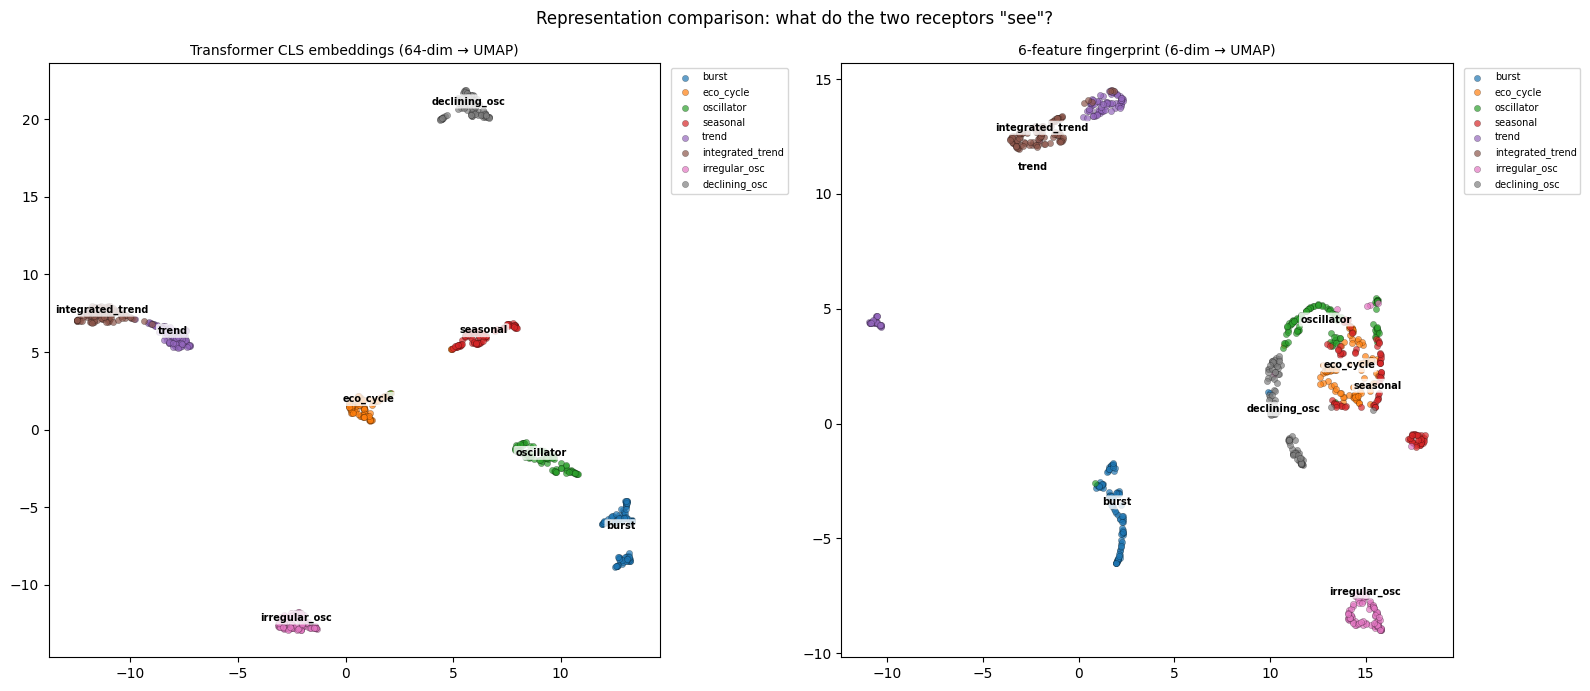

In [14]:
# ============================================================
# Side-by-side UMAP: transformer embeddings vs 6-feature
# ============================================================

reducer_6f = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
umap_6f    = reducer_6f.fit_transform(X_6f)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, emb, title in [
    (axes[0], emb_umap, 'Transformer CLS embeddings (64-dim → UMAP)'),
    (axes[1], umap_6f,  '6-feature fingerprint (6-dim → UMAP)'),
]:
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = y_emb == cls_id
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[palette[cls_id]], s=20, alpha=0.7,
                   edgecolors='k', linewidths=0.2, label=cls_name)
        cx, cy = emb[mask, 0].mean(), emb[mask, 1].mean()
        ax.annotate(cls_name, (cx, cy), fontsize=7, fontweight='bold',
                    ha='center', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='none'))
    ax.set_title(title, fontsize=10)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.suptitle('Representation comparison: what do the two receptors "see"?', fontsize=12)
plt.tight_layout()
plt.show()

---
## Findings — Notebook 25

### Finding 64: No grokking — XWorld shape classes are immediately generalizable

**Prediction:** Val acc will plateau then jump (grokking).

**Result:** WRONG — train and val both hit >90% at epoch 50 (first checkpoint). Zero memorization gap. The waveforms are visually distinct enough that a transformer classifies them directly. Grokking requires tasks where no surface pattern is sufficient; XWorld shape classes are the opposite.

---

### Finding 65: Address-book geometry, not a manifold

**Prediction:** 8 clusters with continuous structure between them.

**Result:** WRONG — pairwise centroid distances compressed to 10.3–13.1 (range = 2.8, ratio = 1.27x). All classes roughly equidistant. Cross-entropy training pushes classes to maximally separated corners; it does not encode similarity between classes.

---

### Finding 66: Transformer vs 6-feature — Spearman ρ = −0.31

**Prediction:** ρ > 0.6 (close agreement).

**Result:** WRONG sign — ρ = −0.31 (p = 0.11). Transformer most distant pair: irregular_osc ↔ declining_osc (13.06). In 6-feature space these are the most frequent confusion pair (nb23 F57). The 3 validation errors (eco_cycle→seasonal, trend↔integrated_trend) agree with the 6-feature closest pairs — the confusions agree, the distances don't.

**The result that matters:** Both receptors separate all 8 classes cleanly. The 8 boundaries are robust. But the geometry between classes is receptor-dependent. The 8 separations are in the world; the manifold between them is in the measurement.
